# 5. Marketing's hypothesis

**Week 1, Tuesday. Chapter 5 of 6.** By the end of this notebook you can test Marketing's acquisition claim in its own terms, catch a helper that drops a segment without a word, and size the paid tier's fall against the business it belongs to.

> **Marketing pushes back.** "A flat count can hide churn replaced by new customers, which is why we
> need acquisition. And Retail-Plus is Rs 65,250 out of a Rs 23 lakh fall. Last quarter's summary
> script says Business fell most; it does not matter."
>
> The marketing lead, Kalpa Retail

**What chapter 4 established, and what this adds.** The rise in revenue per order is about 69
percent mix: 25 small Retail-Plus orders disappeared, and no consumer segment paid meaningfully more. Marketing now attacks the
finding on three fronts. This chapter adds two tools: a set of customer ids per quarter, which
answers the churn claim, and a small helper that turns two numbers into a percentage change, which
has to be checked before anyone trusts its summary.

> **Kavya's review of chapter 4.** "You told Marketing the consumer segments did not pay more. Expect them to come back
> with a better argument, and answer it with a check they can run themselves."

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
ORDERS = kit.load_records("C2_W01_D02_orders_STUDENT.py")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Business", "Student"]
groups = {"Q1": {}, "Q2": {}}       # quarter -> segment -> list of orders
by_quarter = {"Q1": [], "Q2": []}
for order in ORDERS:
    q, seg = order["quarter"], order["segment"]
    groups[q].setdefault(seg, []).append(order)
    by_quarter[q].append(order)


def tree_for(rows):
    """The revenue tree's leaves for any list of orders, returned as a dictionary (chapter 3)."""
    revenue = 0
    seen = {}
    for order in rows:
        revenue += order["amount"]
        seen[order["customer_id"]] = True
    orders = len(rows)
    customers = len(seen)
    return {"revenue": revenue, "orders": orders, "customers": customers,
            "orders_per_customer": orders / customers,
            "revenue_per_order": revenue / orders}


def describe(amounts):
    """A group's typical value and spread: median, min, max and range (chapter 3)."""
    ordered = sorted(amounts)
    n = len(ordered)
    if n % 2 == 1:
        median = ordered[n // 2]
    else:
        median = (ordered[n // 2 - 1] + ordered[n // 2]) / 2
    return {"median": median, "min": ordered[0], "max": ordered[-1], "range": ordered[-1] - ordered[0]}

q1 = {seg: tree_for(groups["Q1"][seg]) for seg in SEGMENTS}
q2 = {seg: tree_for(groups["Q2"][seg]) for seg in SEGMENTS}
print("segments carried from chapter 3:", ", ".join(SEGMENTS))

segments carried from chapter 3: Retail-Core, Retail-Plus, Business, Student


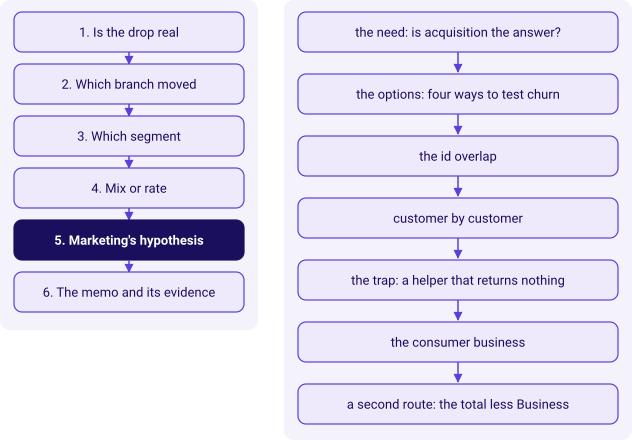

In [2]:
kit.side_by_side(
    kit.ladder(['Is the drop real', 'Which branch moved', 'Which segment', 'Mix or rate', "Marketing's hypothesis", 'The memo and its evidence'], lit=4, show=False),
    kit.vflow(['the need: is acquisition the answer?', 'the options: four ways to test churn', 'the id overlap', 'customer by customer', 'the trap: a helper that returns nothing', 'the consumer business', 'a second route: the total less Business'], show=False),
)

## The need

Marketing's Rs 12 crore rests on one claim: Kalpa is losing customers and must replace them. The
metric at stake is retention, the customers of Q1 who bought again in Q2, and its mirror, the new
customers of Q2. The decision riding on it is the acquisition budget itself. A wrong answer costs
either Rs 12 crore spent replacing customers who never left, or a retention problem left to run
while the money goes elsewhere.

**Who else faces this.** Every membership business runs Marketing's argument against the
frequency argument. Harvard Business Review summarised the studies behind it: depending on the study
and the industry, acquiring a new customer costs 5 to 25 times more than retaining an existing one,
and Bain's Frederick Reichheld found that a 5 percent rise in retention lifts profits by 25 to 95
percent (Amy Gallo, HBR, 29 October 2014, checked 30 Sep 2026). Those are estimates across
industries, never Kalpa's figures, so the reply asks Finance for Kalpa's own acquisition cost. Swiggy
shows why the two branches are reported apart: in the quarter to September 2025 its monthly
transacting users rose 34.0 percent in a year to 22.9 million while orders per user a month fell from
4.53 to 4.10 (Swiggy, Q2 FY2026 shareholder letter, checked 30 Sep 2026). A count and a frequency can move apart, which is why each is reported on its own, the reverse of Kalpa's quarter and the same lesson.

## The options

Four ways to test "a flat count hides churn replaced by new customers".

| Option | How | Can it see churn? |
|---|---|---|
| A. Compare the counts | 69 in Q1 against 69 in Q2 | No: a count is net, so 20 lost and 20 new also give 69 and 69 |
| B. The id overlap | A set of ids per quarter; in both, only in Q1, only in Q2 | Yes, lost and new named separately |
| C. Customer by customer | Each id's Q1 and Q2 orders side by side | Yes, and who slowed down as well |
| D. Ask Marketing's CRM | New sign-ups by month from the campaign system | Only new customers, from a second system to reconcile |

The cell below sizes each on this file.

Option,Rows read,Output to read,Sees lost and new?
A. counts,200,2 numbers,no
B. id overlap,200,3 numbers,yes
C. customer by customer,200,69 rows,"yes, and who slowed"
D. Marketing's CRM,another system,sign-ups by month,new only


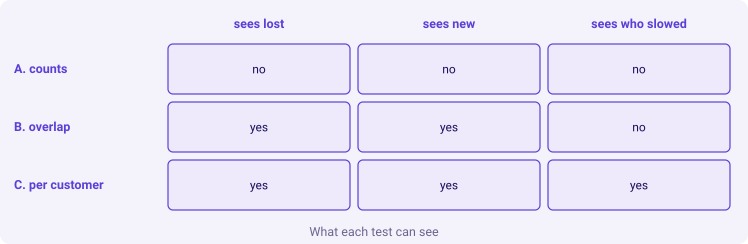

In [3]:
ids = {"Q1": set(), "Q2": set()}
per_customer = {"Q1": {}, "Q2": {}}
for order in ORDERS:
    q, cid = order["quarter"], order["customer_id"]
    ids[q].add(cid)
    per_customer[q][cid] = per_customer[q].get(cid, 0) + 1
kit.table(["Option", "Rows read", "Output to read", "Sees lost and new?"],
          [("A. counts", 200, "2 numbers", "no"),
           ("B. id overlap", 200, "3 numbers", "yes"),
           ("C. customer by customer", 200, f"{len(ids['Q1'] | ids['Q2'])} rows", "yes, and who slowed"),
           ("D. Marketing's CRM", "another system", "sign-ups by month", "new only")],
          caption="Sizing four tests of the churn claim")
kit.matrix(["A. counts", "B. overlap", "C. per customer"], ["sees lost", "sees new", "sees who slowed"],
           [["no", "no", "no"], ["yes", "yes", "no"], ["yes", "yes", "yes"]],
           title="What each test can see")
kit.check("the two quarters hold 69 distinct customer ids between them", len(ids["Q1"] | ids["Q2"]) == 69)

**The best-fit call.** Option B, the id overlap, because it answers Marketing's claim exactly, lost
and new, in three numbers anyone can rerun; option C follows it because the next question is who
slowed. **The fact that would change the call:** if the ids were not stable, for example if the
store and the app gave the same person two ids, the overlap would invent churn, and the CRM, option
D, would be needed to join them first.

## 1. All 69 customers bought in both quarters

**Predict before you run.** How many of Q1's 69 customers are missing from Q2? a) about 20, replaced
by 20 new ones; b) about 5; c) none; d) it cannot be told from one export.

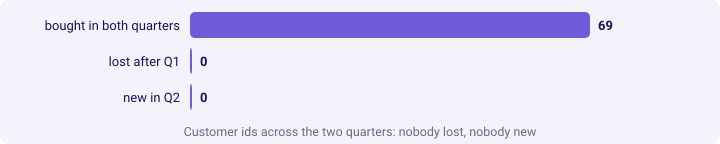

In [4]:
both = ids["Q1"] & ids["Q2"]
lost = ids["Q1"] - ids["Q2"]
new = ids["Q2"] - ids["Q1"]
kit.bars([("bought in both quarters", len(both)), ("lost after Q1", len(lost)), ("new in Q2", len(new))],
         title="Customer ids across the two quarters: nobody lost, nobody new")
kit.check("all 69 customers bought in both quarters", len(both) == 69, f"{len(both)}")
kit.check("no customer was lost and none was new", len(lost) == 0 and len(new) == 0, f"{len(lost)} lost, {len(new)} new")

**What happened.** The answer is c. Every one of the 69 Q2 customers bought in Q1: none lost, none
new. The flat count hides no churn, and acquisition has nothing to replace on this file.

## 2. Customer by customer, 23 slowed down and 18 of them are members

Option C: each customer's orders in Q2 minus their orders in Q1.

**Predict before you run.** Of the customers who placed fewer orders in Q2, how many are Retail-Plus
members? a) about a quarter; b) about half; c) most of them; d) none.

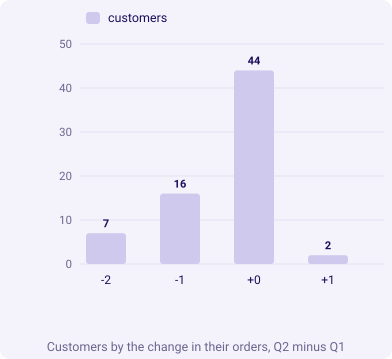

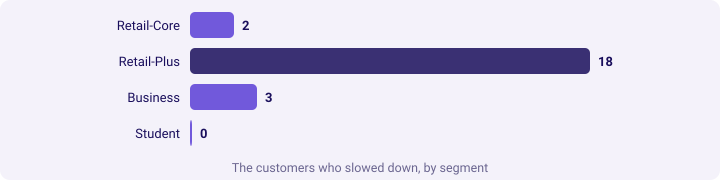

In [5]:
segment_of = {o["customer_id"]: o["segment"] for o in ORDERS}
change_count = {}
slowed_by_segment = {}
for cid in ids["Q1"]:
    d = per_customer["Q2"].get(cid, 0) - per_customer["Q1"][cid]
    change_count[d] = change_count.get(d, 0) + 1
    if d < 0:
        slowed_by_segment[segment_of[cid]] = slowed_by_segment.get(segment_of[cid], 0) + 1
kit.columns([f"{d:+d}" for d in sorted(change_count)], [("customers", [change_count[d] for d in sorted(change_count)])],
            title="Customers by the change in their orders, Q2 minus Q1")
kit.bars([(seg, slowed_by_segment.get(seg, 0)) for seg in SEGMENTS], lit=[1],
         title="The customers who slowed down, by segment")
kit.check("23 customers placed fewer orders in Q2", sum(slowed_by_segment.values()) == 23)
kit.check("18 of the 23 are Retail-Plus members", slowed_by_segment.get("Retail-Plus", 0) == 18)

**What happened.** The answer is c. Twenty-three customers placed fewer orders, and eighteen of them
are Retail-Plus members; 44 customers ordered exactly as often as before. The fall is people Kalpa
already has, buying less often, and most of them pay for membership.

## 3. The trap: last quarter's summary script says Business fell most

Marketing's third point comes from a colleague's script, left over from last quarter's report. Run it
exactly as it is, then read what the summary says.

**Predict before you run.** The script summarises the fall in orders per customer by segment. Which
segment will it say fell most? a) Retail-Plus; b) Business; c) Retail-Core; d) Student.

**The plausible wrong answer.** The script runs, prints a tidy summary, and nobody counts what came
back.

In [6]:
def pct_change(before, after):
    change = 100 * (after - before) / before
    if abs(change) > 30:
        print(f"  check by hand: {change:+.1f}%")
    else:
        return round(change, 1)

changes = {}
for seg in SEGMENTS:
    changes[seg] = pct_change(q1[seg]["orders_per_customer"], q2[seg]["orders_per_customer"])
falls = {}
for seg, ch in changes.items():
    if ch and ch < 0:
        falls[seg] = ch
print("summary:", falls)
print("orders per customer fell in every segment, most in Business,", min(falls.values()), "percent")
kit.check("the summary names Business as the largest fall", min(falls, key=falls.get) == "Business")

  check by hand: -49.0%
  check by hand: +40.0%
summary: {'Retail-Core': -5.3, 'Business': -15.0}
orders per customer fell in every segment, most in Business, -15.0 percent


**Why it is wrong.** The answer to the prediction is b, and it is the wrong answer. `pct_change`
prints its warning for any change larger than 30 percent and returns nothing, so Python hands back
`None`. The filter `if ch and ch < 0` then drops every `None` without a word. Retail-Plus, whose
orders per member halved, is exactly the kind of large change the script was written to flag, and it
fell out of the summary. The decision it misleads: Meera opens Business accounts first, and the head
of Retail-Plus is told his tier is not in the table.

**The check** counts the groups in and the groups out: four segments went in.

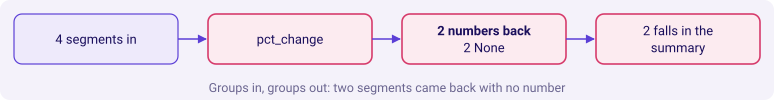

In [7]:
none_back = [seg for seg, ch in changes.items() if ch is None]
kit.flow(["4 segments in", "pct_change", f"{len(SEGMENTS) - len(none_back)} numbers back\n{len(none_back)} None",
          f"{len(falls)} falls in the summary"], kinds=["plain", "bad", "bad", "bad"],
         title="Groups in, groups out: two segments came back with no number")
kit.check("two of the four segments came back as None", len(none_back) == 2, ", ".join(none_back))

**The fix.** Return the change every time, in the same type, and put the "check by hand" flag in a
column of its own, so large moves are flagged instead of dropped.

Segment,Q1,Q2,Change,Flag
Retail-Core,1.12,1.06,-5.3%,
Retail-Plus,2.32,1.18,-49.0%,check by hand
Business,1.82,1.55,-15.0%,
Student,2.50,3.50,+40.0%,check by hand


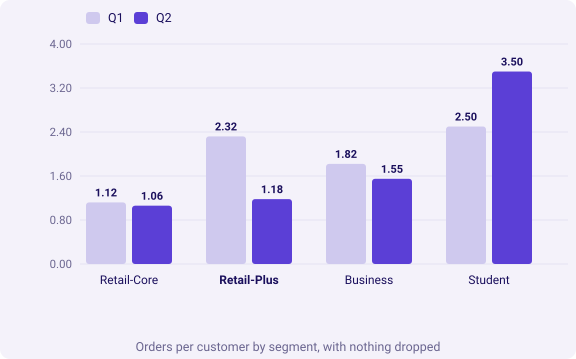

In [8]:
def pct_change_fixed(before, after):
    return round(100 * (after - before) / before, 1)

fixed = {seg: pct_change_fixed(q1[seg]["orders_per_customer"], q2[seg]["orders_per_customer"]) for seg in SEGMENTS}
kit.table(["Segment", "Q1", "Q2", "Change", "Flag"],
          [(seg, f'{q1[seg]["orders_per_customer"]:.2f}', f'{q2[seg]["orders_per_customer"]:.2f}', f"{fixed[seg]:+.1f}%",
            "check by hand" if abs(fixed[seg]) > 30 else "") for seg in SEGMENTS],
          caption="Orders per customer: every segment, every change")
kit.columns(SEGMENTS, [("Q1", [round(q1[s]["orders_per_customer"], 2) for s in SEGMENTS]),
                       ("Q2", [round(q2[s]["orders_per_customer"], 2) for s in SEGMENTS])],
            fmt=lambda v: f"{v:.2f}", lit=[1], title="Orders per customer by segment, with nothing dropped")
kit.check("the fixed summary has a number for every segment", None not in fixed.values() and len(fixed) == 4)
kit.check("Retail-Plus fell 49.0 percent and Student rose 40.0", (fixed["Retail-Plus"], fixed["Student"]) == (-49.0, 40.0))

**What changed.** "Business fell most, 15.0 percent" became "Retail-Plus fell 49.0 percent, 2.32 to
1.18 orders per member, and Business 15.0 percent on three orders". Student, which rose 40.0 percent
on two customers, also went missing from the broken script, and the filter would have dropped it
anyway because it rose.

## 4. Too small to matter? The consumer business, in its own terms

Marketing's rupee point is correct arithmetic and the wrong comparison. Business orders run to lakhs
and consumer orders to a few thousand rupees, so a consumer segment is judged against the consumer
business.

**Predict before you run.** What share of the consumer business's fall is Retail-Plus? a) about 3
percent; b) about a third; c) about 93 percent; d) all of it.

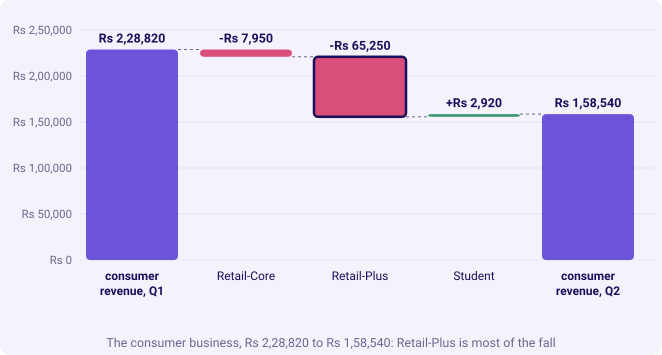

In [9]:
CONSUMER = ["Retail-Core", "Retail-Plus", "Student"]
consumer_q1 = sum(q1[s]["revenue"] for s in CONSUMER)
consumer_q2 = sum(q2[s]["revenue"] for s in CONSUMER)
consumer_fall = consumer_q1 - consumer_q2
plus_fall = q1["Retail-Plus"]["revenue"] - q2["Retail-Plus"]["revenue"]
kit.bridge(("consumer revenue, Q1", consumer_q1), [(s, q2[s]["revenue"] - q1[s]["revenue"]) for s in CONSUMER],
           end_label="consumer revenue, Q2", lit=[1],
           title="The consumer business, Rs 2,28,820 to Rs 1,58,540: Retail-Plus is most of the fall")
kit.check("the consumer business fell Rs 70,280", consumer_fall == 70280, kit.rupees(consumer_fall))
kit.check("Retail-Plus is 93 percent of the consumer fall", round(plus_fall / consumer_fall * 100) == 93,
          f"{plus_fall / consumer_fall * 100:.1f}")

**What happened.** The answer is c. Retail-Plus is Rs 65,250 of the Rs 70,280 consumer fall, 93
percent, and 25 of the 28 lost orders. The rupee fall in Business rests on three orders out of
twenty, each worth lakhs, which is too few to call a trend before anyone builds on it. The two
findings go to Meera side by side: the rupees in Business, with their caveat, and the behaviour in
Retail-Plus, with its count.

## A second route: the whole fall less Business

The bridge added three consumer segments' moves. The second route takes the company's fall and
removes Business; the two must agree to the rupee.

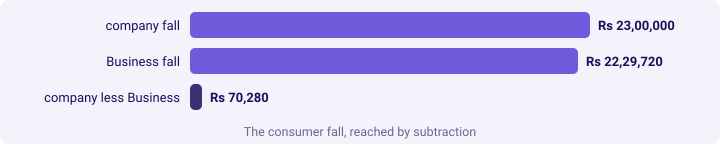

In [10]:
total_fall = sum(q1[s]["revenue"] for s in SEGMENTS) - sum(q2[s]["revenue"] for s in SEGMENTS)
business_fall = q1["Business"]["revenue"] - q2["Business"]["revenue"]
route_two = total_fall - business_fall
kit.bars([("company fall", total_fall), ("Business fall", business_fall), ("company less Business", route_two)],
         fmt=kit.rupees, lit=[2], title="The consumer fall, reached by subtraction")
kit.check("both routes give Rs 70,280", route_two == consumer_fall, kit.rupees(route_two))

**When to switch.** Subtraction is quicker and hides which consumer segment moved; the bridge is the
one to show when the question is who.

> **Kavya's review.** "Three attacks, three checks anyone can rerun: the overlap for churn, groups in
> and out for the script, and the consumer business for size. And you nearly shipped a summary that
> lost the one segment that matters. Count what comes back from every helper you did not write."

### In the interview

**[D] Marketing insists the answer is acquisition and your data says frequency; how do you make the
case in the room?** "I take their claim seriously and test it in its own terms, with a check they can
repeat. Acquisition predicts more customers, or churn replaced by new ones, so I show the count, 69
and 69, and the overlap: every Q2 customer bought in Q1, none lost, none new. Then I show where the
fall is, orders per customer from 1.65 to 1.25, and in the consumer business Retail-Plus is 93
percent of the fall. I end on what would change my mind, which keeps it a question of evidence."
The interviewer is listening for the test that would falsify Marketing's claim, and a calm tone.

**[F] Why does a function that prints instead of returning break a pipeline?** "Printing sends the
answer to the screen and returns `None` to the caller. The next step receives `None` and either
crashes or, worse, carries on: here a filter dropped every `None` and two of four segments vanished
from the summary, including the one that fell 49 percent. A function returns its answer every time,
in the same type, and a flag goes in its own column." The interviewer is listening for `None`, the
silent case, and computing kept apart from showing.

**[SV] The customer count is flat quarter on quarter; does that prove no customers were lost?** "No;
a count is net. The test is the overlap of ids: in both periods, only in the first, only in the
second. Here it came out 69, 0 and 0." The interviewer is listening for overlap, lost and new.

**The design question. How would you test "a flat count hides churn", and what would make you
distrust your own test?** "The id overlap, because it names lost and new separately in three numbers.
I would distrust it if one person can hold two ids, say one from the store and one from the app,
since then the overlap invents churn; I would join the ids through the CRM first." The interviewer
is listening for the assumption under the test.

### Depth: when ids are not people

Try it: invent five orders where one customer shops in the store as `C-9001` and in the app as
`C-9002`, and show that the overlap reports one lost and one new customer who is the same person.

References for the chapter:

- Amy Gallo, "The Value of Keeping the Right Customers", Harvard Business Review, 29 October 2014: https://hbr.org/2014/10/the-value-of-keeping-the-right-customers (verified 30 Sep 2026)
- Python docs, sets: https://docs.python.org/3/tutorial/datastructures.html#sets (verified 30 Sep 2026)

In [11]:
kit.check_summary()
print("Next: chapter 6, the head of Retail-Plus hands us a cause, and the memo says what would settle it.")

Next: chapter 6, the head of Retail-Plus hands us a cause, and the memo says what would settle it.
